In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
import os

path = '/content/drive/MyDrive/camera_dataset'
files = os.listdir(path)
for file in files:
    print(file)

camera_model.h5
blank.mp4
blur.mp4
haze.mp4
low_light.mp4
normal.mp4
occlusion.mp4


In [7]:
def extract_frames(video_name, category, every_nth_frame=2, max_frames=5000):
    cap = cv2.VideoCapture(f'{video_path}/{video_name}')
    count = 0
    saved = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if count % every_nth_frame == 0 and saved < max_frames:
            filename = f'/content/dataset/{category}/{category}_{saved}.jpg'
            cv2.imwrite(filename, frame)
            saved += 1

        if saved >= max_frames:
            break

        count += 1

    cap.release()
    print(f'✅ {category}: {saved} frames extracted')

# Extract all 6 videos
extract_frames('normal.mp4', 'normal')
extract_frames('blur.mp4', 'blur')
extract_frames('blank.mp4', 'blank')
extract_frames('occlusion.mp4', 'occlusion')
extract_frames('low_light.mp4', 'low_light')
extract_frames('haze.mp4', 'haze')

✅ normal: 5000 frames extracted
✅ blur: 5000 frames extracted
✅ blank: 1855 frames extracted
✅ occlusion: 4981 frames extracted
✅ low_light: 5000 frames extracted
✅ haze: 5000 frames extracted


In [8]:
import os

categories = ['normal', 'blur', 'blank', 'occlusion', 'low_light', 'haze']

total = 0
for category in categories:
    path = f'/content/dataset/{category}'
    count = len(os.listdir(path))
    total += count
    print(f'{category}: {count} images')

print(f'\nTotal images: {total}')

normal: 12930 images
blur: 12028 images
blank: 1855 images
occlusion: 4981 images
low_light: 5000 images
haze: 5000 images

Total images: 41794


In [9]:
import os
import random

categories = ['normal', 'blur', 'blank', 'occlusion', 'low_light', 'haze']
MAX_IMAGES = 1855  # Use minimum count to keep balanced

for category in categories:
    path = f'/content/dataset/{category}'
    files = os.listdir(path)

    if len(files) > MAX_IMAGES:
        # Delete extra files
        files_to_delete = random.sample(files, len(files) - MAX_IMAGES)
        for file in files_to_delete:
            os.remove(f'{path}/{file}')

    print(f'✅ {category}: {len(os.listdir(path))} images')

print(f'\nDataset balanced!')

✅ normal: 1855 images
✅ blur: 1855 images
✅ blank: 1855 images
✅ occlusion: 1855 images
✅ low_light: 1855 images
✅ haze: 1855 images

Dataset balanced!


In [10]:
import os

categories = ['normal', 'blur', 'occlusion', 'low_light', 'haze']

for category in categories:
    os.makedirs(f'/content/dataset/{category}', exist_ok=True)

def extract_frames(video_name, category, every_nth_frame=2, max_frames=5000):
    cap = cv2.VideoCapture(f'{video_path}/{video_name}')
    count = 0
    saved = 0

    # Clear existing images first
    path = f'/content/dataset/{category}'
    for f in os.listdir(path):
        os.remove(f'{path}/{f}')

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if count % every_nth_frame == 0 and saved < max_frames:
            filename = f'{path}/{category}_{saved}.jpg'
            cv2.imwrite(filename, frame)
            saved += 1

        if saved >= max_frames:
            break

        count += 1

    cap.release()
    print(f'✅ {category}: {saved} frames extracted')

# Re-extract 5000 for these 5 categories
extract_frames('normal.mp4', 'normal')
extract_frames('blur.mp4', 'blur')
extract_frames('occlusion.mp4', 'occlusion')
extract_frames('low_light.mp4', 'low_light')
extract_frames('haze.mp4', 'haze')

✅ normal: 5000 frames extracted
✅ blur: 5000 frames extracted
✅ occlusion: 4981 frames extracted
✅ low_light: 5000 frames extracted
✅ haze: 5000 frames extracted


In [ ]:
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split

categories = ['normal', 'blur', 'blank', 'occlusion', 'low_light', 'haze']
IMG_SIZE = 224

X = []
y = []

for label, category in enumerate(categories):
    path = f'/content/dataset/{category}'
    for image_file in os.listdir(path):
        img = cv2.imread(f'{path}/{image_file}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img)
        y.append(label)
    print(f'✅ {category} loaded with label {label}')

X = np.array(X) / 255.0
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'\nTraining images: {X_train.shape}')
print(f'Testing images: {X_test.shape}')

✅ normal loaded with label 0
✅ blur loaded with label 1
✅ blank loaded with label 2
✅ occlusion loaded with label 3
✅ low_light loaded with label 4
✅ haze loaded with label 5


In [3]:
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

categories = ['normal', 'blur', 'blank', 'occlusion', 'low_light', 'haze']
IMG_SIZE = 64

# First mount drive again
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split

categories = ['normal', 'blur', 'blank', 'occlusion', 'low_light', 'haze']
IMG_SIZE = 64
MAX_PER_CATEGORY = 1855  # Use same count for all to balance

X = []
y = []

for label, category in enumerate(categories):
    path = f'/content/dataset/{category}'
    files = os.listdir(path)[:MAX_PER_CATEGORY]  # Take only 1855 from each

    for image_file in files:
        img = cv2.imread(f'{path}/{image_file}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img)
        y.append(label)

    print(f'✅ {category}: {len(files)} images loaded')

X = np.array(X, dtype=np.float32) / 255.0
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'\nTraining images: {X_train.shape}')
print(f'Testing images: {X_test.shape}')

✅ normal: 1855 images loaded
✅ blur: 1855 images loaded
✅ blank: 1855 images loaded
✅ occlusion: 1855 images loaded
✅ low_light: 1855 images loaded
✅ haze: 1855 images loaded

Training images: (8904, 64, 64, 3)
Testing images: (2226, 64, 64, 3)


In [5]:
import os
import shutil

categories = ['normal', 'blur', 'blank', 'occlusion', 'low_light', 'haze']

# Create train and test folders
for category in categories:
    os.makedirs(f'/content/data/train/{category}', exist_ok=True)
    os.makedirs(f'/content/data/test/{category}', exist_ok=True)

# Split and move images
import random

for category in categories:
    path = f'/content/dataset/{category}'
    files = os.listdir(path)
    random.shuffle(files)

    # 80% train 20% test
    split = int(len(files) * 0.8)
    train_files = files[:split]
    test_files = files[split:]

    for f in train_files:
        shutil.copy(f'{path}/{f}', f'/content/data/train/{category}/{f}')

    for f in test_files:
        shutil.copy(f'{path}/{f}', f'/content/data/test/{category}/{f}')

    print(f'✅ {category}: {len(train_files)} train | {len(test_files)} test')

✅ normal: 4000 train | 1000 test
✅ blur: 4000 train | 1000 test
✅ blank: 1484 train | 371 test
✅ occlusion: 3984 train | 997 test
✅ low_light: 4000 train | 1000 test
✅ haze: 4000 train | 1000 test


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 64
BATCH_SIZE = 32

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/data/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

test_generator = test_datagen.flow_from_directory(
    '/content/data/test',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

print(f'\nClasses: {train_generator.class_indices}')

Found 21468 images belonging to 6 classes.
Found 5368 images belonging to 6 classes.

Classes: {'blank': 0, 'blur': 1, 'haze': 2, 'low_light': 3, 'normal': 4, 'occlusion': 5}


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input

model = Sequential([
    Input(shape=(64, 64, 3)),

    # First Layer
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Second Layer
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Third Layer
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Classify
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,275,590 (4.87 MB)

 Trainable params: 1,275,142 (4.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',  # Watch validation accuracy
    patience=3,              # Stop if no improvement for 3 epochs
    restore_best_weights=True # Keep best model weights
)

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator,
    callbacks=[early_stop]
)

Epoch 1/15
671/671 ━━━━━━━━━━━━━━━━━━━━ 128s 191ms/step - accuracy: 0.9826 - loss: 0.0935 - val_accuracy: 0.9765 - val_loss: 0.1384
Epoch 2/15
671/671 ━━━━━━━━━━━━━━━━━━━━ 129s 192ms/step - accuracy: 0.9815 - loss: 0.1013 - val_accuracy: 0.7820 - val_loss: 1.2774
Epoch 3/15
671/671 ━━━━━━━━━━━━━━━━━━━━ 125s 186ms/step - accuracy: 0.9921 - loss: 0.0378 - val_accuracy: 0.9398 - val_loss: 0.3629
Epoch 4/15
671/671 ━━━━━━━━━━━━━━━━━━━━ 131s 196ms/step - accuracy: 0.9889 - loss: 0.0646 - val_accuracy: 0.9862 - val_loss: 0.0631
Epoch 5/15
671/671 ━━━━━━━━━━━━━━━━━━━━ 130s 193ms/step - accuracy: 0.9908 - loss: 0.0526 - val_accuracy: 0.9844 - val_loss: 0.1195
Epoch 6/15
671/671 ━━━━━━━━━━━━━━━━━━━━ 128s 191ms/step - accuracy: 0.9897 - loss: 0.0700 - val_accuracy: 0.9788 - val_loss: 0.1029
Epoch 7/15
671/671 ━━━━━━━━━━━━━━━━━━━━ 123s 183ms/step - accuracy: 0.9890 - loss: 0.0566 - val_accuracy: 0.9542 - val_loss: 0.2926


In [10]:
model.save('/content/drive/MyDrive/camera_dataset/camera_model_v2.keras')
print("✅ Model saved successfully!")

✅ Model saved successfully!


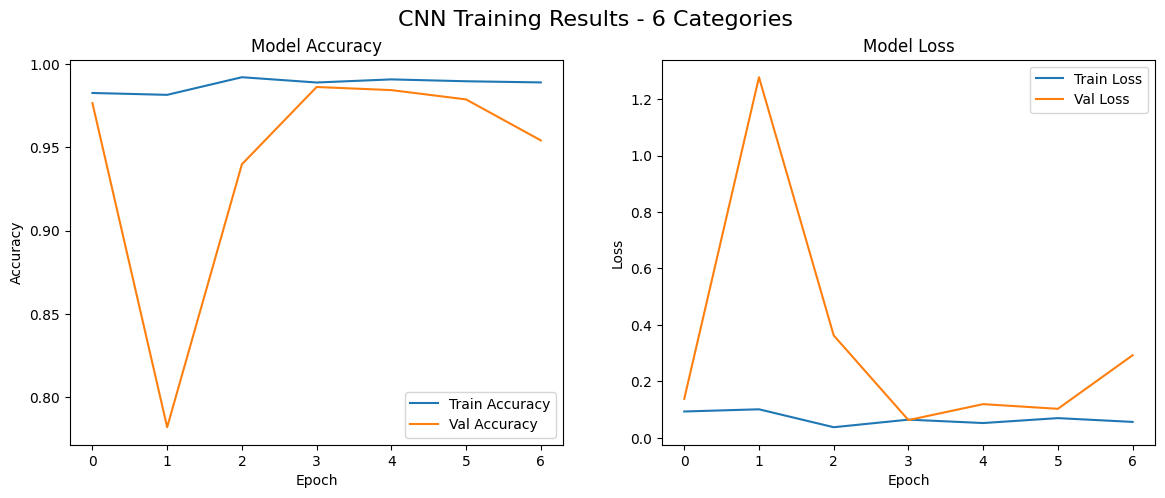

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('CNN Training Results - 6 Categories', fontsize=16)
plt.show()

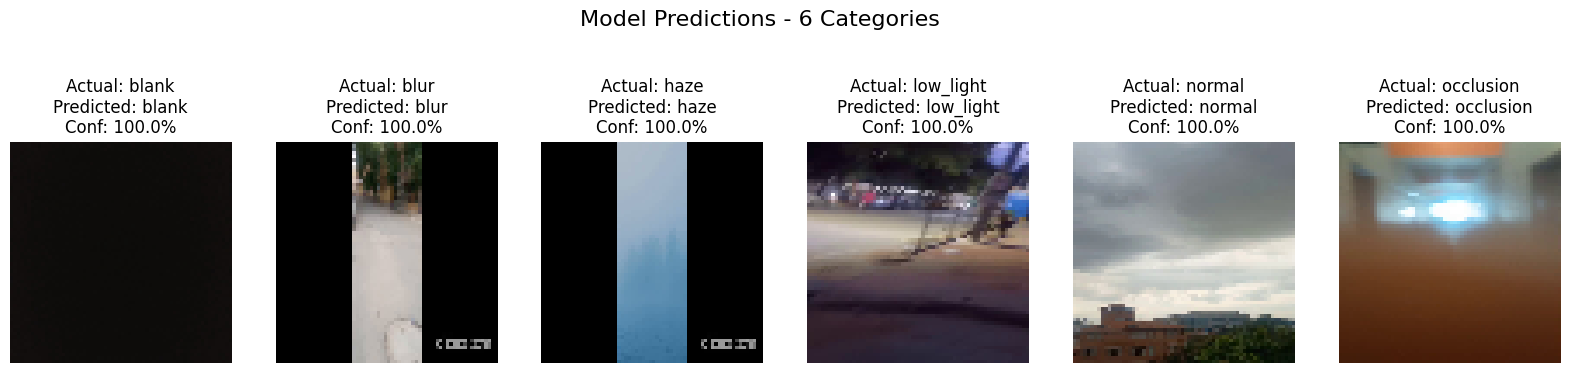

In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

categories = ['blank', 'blur', 'haze', 'low_light', 'normal', 'occlusion']

fig, axes = plt.subplots(1, 6, figsize=(20, 5))

for i, category in enumerate(categories):
    path = f'/content/data/test/{category}'
    image_file = os.listdir(path)[0]

    img = cv2.imread(f'{path}/{image_file}')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (64, 64))

    img_input = np.expand_dims(img_resized, axis=0) / 255.0
    prediction = model.predict(img_input, verbose=0)
    predicted_class = categories[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    axes[i].imshow(img_resized)
    axes[i].set_title(f'Actual: {category}\nPredicted: {predicted_class}\nConf: {confidence:.1f}%')
    axes[i].axis('off')

plt.suptitle('Model Predictions - 6 Categories', fontsize=16)
plt.show()

In [13]:
import shutil

# Zip training dataset
shutil.make_archive(
    '/content/drive/MyDrive/camera_dataset/train_data',
    'zip',
    '/content/data/train'
)
print("✅ Training dataset zipped!")

# Zip testing dataset
shutil.make_archive(
    '/content/drive/MyDrive/camera_dataset/test_data',
    'zip',
    '/content/data/test'
)
print("✅ Testing dataset zipped!")

✅ Training dataset zipped!
✅ Testing dataset zipped!
